# Preparation

📘 1. Import (assinging the label as we have worked in previous lessons)
- Numerical Python
- Panel Datas
- `matplotlib.pyplot`
  - Make sure use the `%matplotlib inline`
- seaborns

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

📘 2. Import the dataset contained in the path.

🟠 The headers of the dataframe are in the first column.

<details><summary>Solution</summary>

```python
df = pd.read_csv(path, header = 0)
df.head()
```

</details>

In [2]:
df = pd.read_csv("1_Data/df_nomiss.csv", header = 0)

cols_float = ["bore", "stroke", "price", "peak-rpm","horsepower"]
cols_int = ["normalized-losses"]

df[cols_float] = df[cols_float].astype('float')
df[cols_int] = df[cols_int].astype('int')

df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


# 1. Linear Regression and Multiple Linear Regression

## 1.1 Simple Linear Regression

$$\hat{Y} = a + bX$$

### 1.1.1 Using `scikit-learn`

<details><summary> 🤓 What is `sklearn`? </summary>

`sklearn` (a.k.a. **scikit-learn**) is a **popular Python library for machine learning**.
    
It provides tools for:
    
    - Regression (predicting numbers)
        
    - Classification (predicting categories)
        
    - Clustering
        
    - Preprocessing and evaluation
</details>

<details><summary> 🤓 Why `sklearn.linear_model`? </summary>

`linear_model` is the module that contains **linear models**, like: `LinearRegression`, `Ridge` or `Lasso`.

Other modules are:

```nginx
sklearn
├─ linear_model      → LinearRegression, LogisticRegression
├─ preprocessing     → Scalers, Encoders
├─ model_selection   → train_test_split, cross_val_score
├─ metrics           → mean_squared_error, accuracy_score
├─ ensemble          → RandomForest, GradientBoosting
├─ cluster           → KMeans, DBSCAN
├─ decomposition     → PCA
├─ neighbors         → KNN
├─ svm               → SVC, SVR
└─ pipeline          → Pipeline
```

</details>

📘 3. Import the **`LinearRegression`** class from the **`sklearn.linear_model`** module.

<details><summary>Solution</summary>

```python
from sklearn.linear_model import LinearRegression
```

</details>

In [3]:
from sklearn.linear_model import LinearRegression

📘 4. Create **`X`** containing the feature `highway-mpg`, and **`Y`** containing the target variable `price`.

<details><summary>Solution</summary>

```python
X = df[['highway-mpg']]
Y = df['price']
```

</details>

In [4]:
X = df[['highway-mpg']]
Y = df['price']

📘 5. Instantiate a `LinearRegression` object and assign it to `lm`.

<details><summary>Solution</summary>

```python
lm = LinearRegression()
```

</details>

In [5]:
lm = LinearRegression()

📘 6. Fit the linear regression model `lm` using the feature vector `X` and target vector `Y`.

<details><summary>Solution</summary>

```python
lm.fit(X, Y)
```

</details>

In [6]:
lm.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
print('The intercept for our model is: ', lm.intercept_)
print('The slope for our model is: ', lm.coef_)
print('R-squared is', lm.score(X, Y))

The intercept for our model is:  38423.3058581574
The slope for our model is:  [-821.73337832]
R-squared is 0.4965911884339176


### 1.1.2 Using `statsmodels.api`

<details><summary>🤓 What is `statsmodels`?</summary>
It is a **Python library for statistical modeling and inference**.  It focuses on:

    - Linear and logistic regression
    - ANOVA / statistical tests
    - Time series analysis
    - Generating **detailed summaries** (coefficients, p-values, confidence intervals, R², etc.)
        
Think of it as **the Python equivalent of R’s statistical modeling tools**.
</details>

<details><summary>🤓 Why `statsmodels.api` and not just `statsmodels`?</summary>

`statsmodels` contains **many submodules**. `statsmodels.api` is a **shortcut that exposes the most commonly used classes and functions**.

</details>

<details><summary>🤓 Difference between `statsmodels` and `sklearn`</summary>

| Feature  | `statsmodels`                                                         | `scikit-learn` (`sklearn`)                                     |
| -------- | --------------------------------------------------------------------- | -------------------------------------------------------------- |
| Focus    | Statistical inference and explanation                                 | Machine learning and prediction                                |
| Output   | Detailed summaries (coefficients, p-values, R², confidence intervals) | Predictions, scores (R², accuracy), model pipelines            |
| Use case | Testing hypotheses, regression analysis, econometrics                 | Predictive modeling, classification, clustering                |
| Syntax   | Close to R style                                                      | Pythonic, flexible, geared toward pipelines and large datasets |
| P-values | Yes                                                                   | No (not included)                                              |

</details>

📘 8. Import the library `statsmodels.api` and assign it to `sm`.

<details><summary>Solution</summary>

```python
import statsmodels.api as sm
```

</details>

In [8]:
import statsmodels.api as sm

📘 9. Add a constant to the predictor vector `X`.

<details><summary>Solution</summary>

```python
X_const = sm.add_constant(X)
```

</details>

In [9]:
X_const = sm.add_constant(X)

📘 10. Use `sm.OLS` to create the regression model by providing the outcome variable `Y` and the predictors `X_const` (which already include the constant for the intercept), and then call `.fit()` to estimate the coefficients and save the result in a variable called `simple_OLS`.

<details><summary>Solution</summary>

```python
simple_OLS = sm.OLS(Y, X_const).fit()
```

</details>

In [10]:
simple_OLS = sm.OLS(Y, X_const).fit()

📘 11. Print a full regression summary of `simple_OLS`

🟢 Make sure to use `print()`

<details><summary>Solution</summary>

```python

```

</details>

In [11]:
print(simple_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     196.3
Date:                Sat, 16 May 2026   Prob (F-statistic):           1.75e-31
Time:                        14:29:12   Log-Likelihood:                -2020.8
No. Observations:                 201   AIC:                             4046.
Df Residuals:                     199   BIC:                             4052.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3.842e+04   1843.391     20.844      

### 1.1.3 Graph

📘 12. Create a scatterplot that would display this linear regression.

<details><summary>Solution</summary>

```python
sns.regplot(x="highway-mpg", y="price", data=df)
```

</details>

<Axes: xlabel='highway-mpg', ylabel='price'>

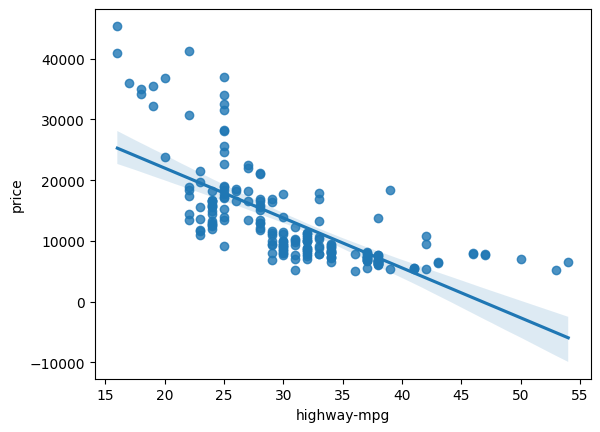

In [12]:
sns.regplot(x="highway-mpg", y="price", data=df)

📘 13. Plot a residual plot for the regression analysis performed.

<details><summary>🤓 What are the residual plot? </summary>

$$e = Y - \hat{Y}$$

We check the differences between the predicted and actual values. If these differences are scattered randomly above and below the line, it shows the model fits well, and using a straight-line (linear) model makes sense.

</details>

<details><summary>Solution</summary>
Using simple `sns`
```python
sns.residplot(x="highway-mpg", y="price", data=df)
```

Using `statsmodels`
```python
sm.graphics.plot_regress_exog(simple_OLS, "highway-mpg")
```

</details>

<Axes: xlabel='highway-mpg', ylabel='price'>

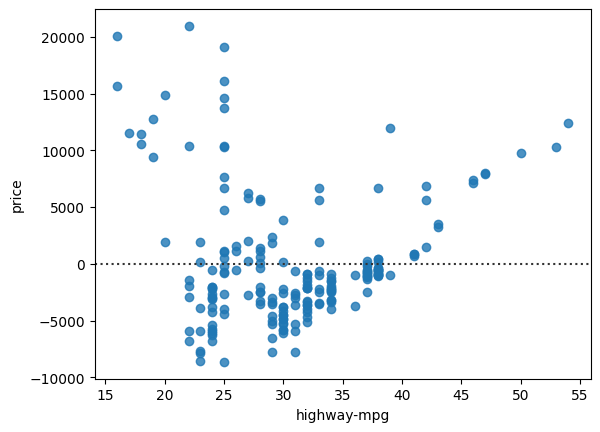

In [13]:
sns.residplot(x="highway-mpg", y="price", data=df)

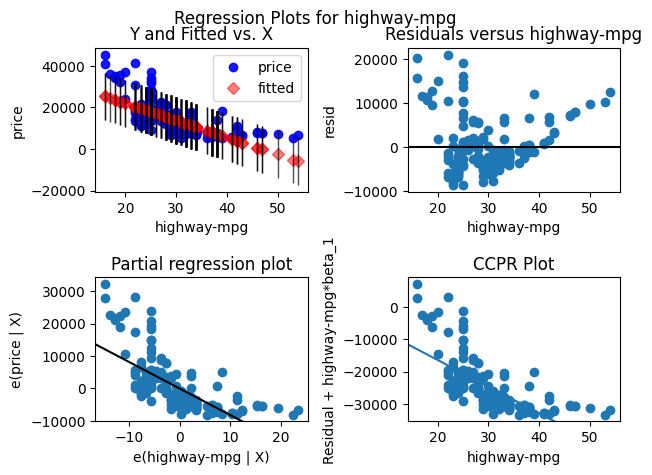

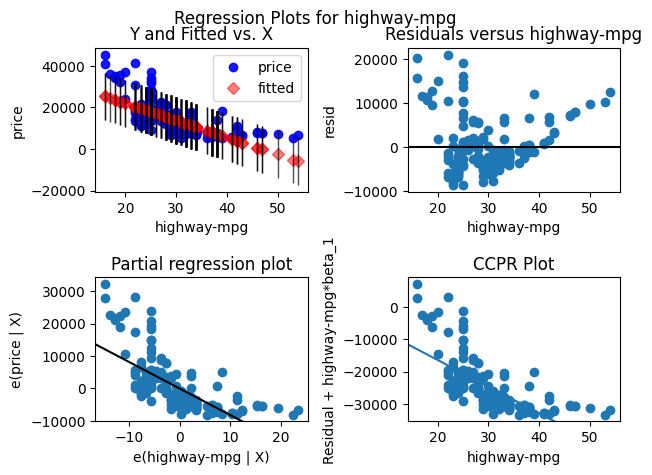

In [14]:
# Alternaly
sm.graphics.plot_regress_exog(simple_OLS, "highway-mpg")

📘 14. Based on the residual plot, what would you say about the linear relationship between `'highway-mpg'` and `'price'`.?

<details><summary>Solution</summary>

Looking at this residual plot, the differences between the predicted and actual values are not scattered randomly—they show a pattern. This suggests that a straight-line model might not capture the data well, and a curved (non-linear) model could be a better fit.

</details>

```python
#Answer
```
Looking at this residual plot, the differences between the predicted and actual values are not scattered randomly—they show a pattern. This suggests that a straight-line model might not capture the data well, and a curved (non-linear) model could be a better fit.

📘 15. Compute the predicted values using the `X`. Storage them as `Y_hat`.

In [15]:
Y_hat = lm.predict(X)

📘 16. Run the code below to get a **distribution plot**. What would you conclude?

🟢 To avoid large warning messages, run the warning line codes

In [16]:
# Warnings
import warnings
warnings.filterwarnings('ignore')

In [17]:
# Predifined function
def dist_plot(y_actuals, y_fitted):
  ax1 = sns.distplot(y_actuals, hist=False, color="r", label="Actual Value")
  sns.distplot(y_fitted, hist=False, color="b", label="Fitted Values" , ax=ax1)


  plt.title('Actual vs Fitted Values for Price')
  plt.xlabel('Price (in dollars)')
  plt.ylabel('Proportion of Cars')

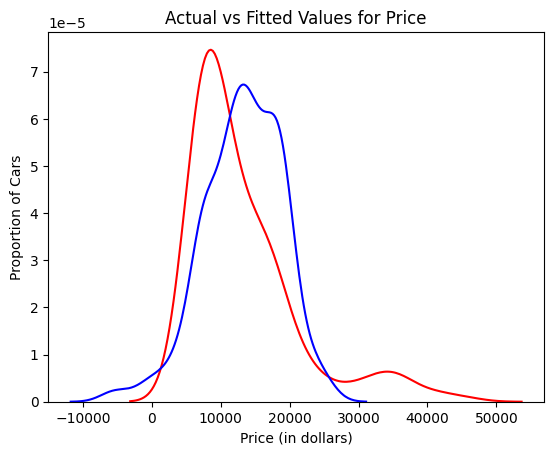

In [18]:
dist_plot(df['price'], Y_hat)

## 1.2 Multiple Linear Regression

$$\hat{Y} = a+ b_1X_1 + b_2X_2 + \dots + b_kX_k$$


📘 17. To create the matrix of explanatory variables, select the columns **horsepower**, **curb-weight**, **engine-size**, and **highway-mpg** from the DataFrame `df` and store them together in a new DataFrame called `X_matrix`.

<details><summary>Solution</summary>

```python
X_vector = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
```

In [19]:
X_matrix = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]

### 1.2.1 Using `scikit-learn`

📘 18.

a. Fit the linear regression model `lm` using the feature matrix `X_matrix` and target vector `Y`.

b. Then print the values of the:
- Intercepts
- Coefficients
- $R^2$

In [20]:
lm.fit(X_matrix, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
print('The intercept is: ', lm.intercept_)
print('The coefficients are: ', lm.coef_)
print('The R^2 is:', lm.score(X_matrix, Y))

The intercept is:  -15824.03820823447
The coefficients are:  [53.61042729  4.70886444 81.47225667 36.39637823]
The R^2 is: 0.8094130135602673


### 1.2.2 Using `statsmodels.api`

📘 19. Use `sm.OLS` to create the regression model by providing the outcome variable `Y` and the predictors set of features of interest and then call `.fit()` to estimate the coefficients and save the result in a variable called `simple_OLS`.

🟠 Add a constant to `X_vector`

Finally, print a full regression summary of `Multiple_OLS`

<details><summary>Solution</summary>

```python
X_matrix_const = sm.add_constant(X_matrix)
Multiple_OLS = sm.OLS(Y, X_matrix_const).fit()
print(Multiple_OLS.summary())
```

In [22]:
X_matrix_const = sm.add_constant(X_matrix)
Multiple_OLS = sm.OLS(Y, X_matrix_const).fit()
print(Multiple_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     208.1
Date:                Sat, 16 May 2026   Prob (F-statistic):           2.26e-69
Time:                        14:29:57   Log-Likelihood:                -1923.2
No. Observations:                 201   AIC:                             3856.
Df Residuals:                     196   BIC:                             3873.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -1.582e+04   4388.105     -3.606      

## 1.3 Performance

📘 20. Compute the predicted values using the `X_matrix`. Storage them as `Y_hat`

<details><summary>Solution</summary>

```python
# Using scikit-learn
Y_hat = lm.predict(X_matrix)
# Using statsmodel.api
Y_hat = Multiple_OLS.fittedvalues
```

</details>

In [23]:
Y_hat = lm.predict(X_matrix)
#Y_hat

In [24]:
Multiple_OLS.fittedvalues

0      13699.001388
1      13699.001388
2      19055.180751
3      10621.208891
4      15519.941331
           ...     
196    16694.805105
197    19508.455476
198    20474.675839
199    17803.263411
200    17103.591058
Length: 201, dtype: float64

📘 21. Can we create a residual plot for multiple linear regression?

<details><summary>🤓 Why not use `sns.residplot()` </summary>

If we perform
```python
sns.residplot(x=X_matrix,y=Y)
```
That would be an error, as the input must be 1D

</details>

<details><summary>Solution</summary>

It can be done, but if the dimension is $\geq 2$, it is difficult to interpreate it

</details>


📘 22. Run the code below to get a **distribution plot**. The, what would you conclude?

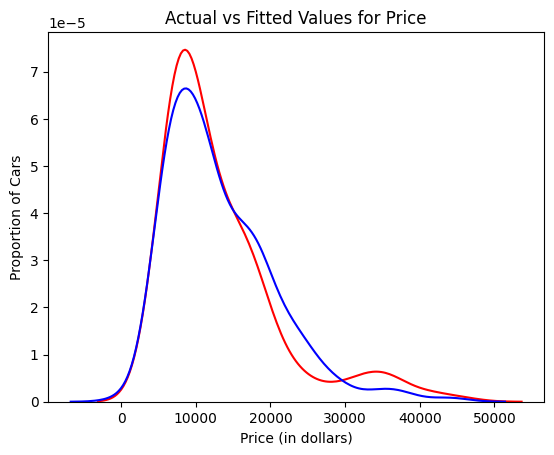

In [25]:
# Just run this code.
dist_plot(df['price'], Y_hat)

```python
# Answer
```
There is an overlap, so it could indicate a better adjustment.

# Polynomial Regression

## 2.1 Single variable

This useful in the presence of non-linear relationships. It can be achived by specify the function form. For example

▶ Quadratic- 2nd order
$$\hat{Y} = a + b_1 X +b_2 X^2$$

▶ Cubic - 3rd Order
$$\hat{Y} = a + b_1 X +b_2 X^2 + b_3 X^3$$


### 2.1.1 In `scikit-learn`

📘 23. Import the **`PolynomialFeatures`** class from the **`sklearn.preprocessing`** module.

<details><summary>Solution</summary>

```python
from sklearn.preprocessing import PolynomialFeatures
```

</details>

In [26]:
from sklearn.preprocessing import PolynomialFeatures

📘 24. Initialize a polynomial transformer of degree 3 and without bias column. Save it as `poly`.

<details><summary>Solution</summary>

```python
poly = PolynomialFeatures(degree=3, include_bias=False
```

</details>

In [27]:
poly = PolynomialFeatures(degree=3, include_bias=False)

25. Transform your predictor variable into polynomial features (`X_poly`). Then check the size of the new variable

In [28]:
X_poly = poly.fit_transform(X)
X_poly.shape

(201, 3)

26. Fit the model using the polynomial features `X_poly` and target `Y`.

Then print the values of the:
- Intercepts
- Coefficients
- $R^2$

In [29]:
lm.fit(X_poly, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
print('The intercept is: ', lm.intercept_)
print('The coefficients are: ', lm.coef_)
print('The R^2 is:', lm.score(X_poly, Y))

The intercept is:  137923.59375769034
The coefficients are:  [-8.96543312e+03  2.04754306e+02 -1.55663829e+00]
The R^2 is: 0.6741946663906517


2.1.2 In `statsmodels`

27. Use `sm.OLS` to create the regression model by providing the outcome variable `Y` and the predictors set of features of interest and then call `.fit()` to estimate the coefficients and save the result in a variable called `simple_OLS`.

🟠 Add a constant to `X_vector`

Finally, print a full regression summary of `poly_OLS`

<details><summary>Solution</summary>

```python

```

In [31]:
X_poly_constant = sm.add_constant(X_poly)
poly_OLS = sm.OLS(Y, X_poly_constant).fit()
print(poly_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     135.9
Date:                Sat, 16 May 2026   Prob (F-statistic):           9.83e-48
Time:                        14:30:24   Log-Likelihood:                -1977.1
No. Observations:                 201   AIC:                             3962.
Df Residuals:                     197   BIC:                             3975.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.379e+05   1.54e+04      8.946      0.0

### 2.1.3 Performance

📘28. Plot a distribution plot using the predicted values from this single polynomial regression performed.

In [32]:
Y_hat = lm.predict(X_poly)

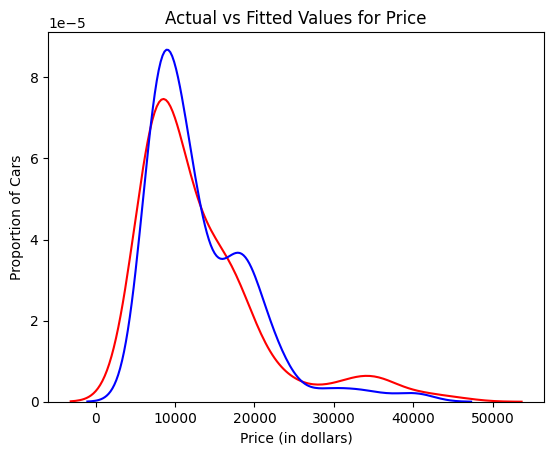

In [33]:
dist_plot(df['price'], Y_hat)

## 2.2 Multiple variable

📘 29. Perform a polynomial regression, but this time using the `X_matrix`.

First, using `scikit-learn`, then `statsmodels.api`.

🔵 29.a. `scikit-learn`

In [34]:
X_matrix_poly = poly.fit_transform(X_matrix)
X_matrix_poly.shape

(201, 34)

In [35]:
lm.fit(X_matrix_poly, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
print('The intercept is: ', lm.intercept_)
print('The coefficients are: ', lm.coef_)
print('The R^2 is:', lm.score(X_matrix_poly, Y))

The intercept is:  -321504.35801821045
The coefficients are:  [-1.72177376e+02 -4.60966931e+01  4.50217662e+03  1.74482714e+04
 -1.36421800e+01  2.36373080e+00 -2.19270790e+01 -8.98186093e+00
 -3.56979178e-03 -1.83732492e+00  3.75032804e+00  1.53257561e+01
 -1.91717224e+02 -3.15663491e+02  3.88288989e-02 -6.54871791e-03
  4.90686017e-02  4.08029898e-01 -6.76278714e-05  7.87268380e-03
 -4.60463639e-02 -6.63474506e-02  8.53898054e-02  5.92474980e-01
 -5.44643068e-06  4.13126357e-04  1.98903131e-04 -7.83248074e-03
  1.58663222e-02 -3.53151688e-02  3.53396382e-02  1.78541694e-01
  1.46764778e+00  1.80597704e+00]
The R^2 is: 0.8952951053261633


🔵 29.b. `statsmodels.api`

In [37]:
X_matrix_poly_constant = sm.add_constant(X_matrix_poly)
poly_multiple_OLS = sm.OLS(Y, X_matrix_poly_constant).fit()
print(poly_multiple_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     41.75
Date:                Sat, 16 May 2026   Prob (F-statistic):           8.95e-65
Time:                        14:30:41   Log-Likelihood:                -1863.0
No. Observations:                 201   AIC:                             3796.
Df Residuals:                     166   BIC:                             3912.
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.215e+05    8.4e+05     -0.383      0.7

📘30. Plot a distribution plot using the predicted values from this multiple polynomial regression performed.

In [38]:
Y_hat = lm.predict(X_matrix_poly)

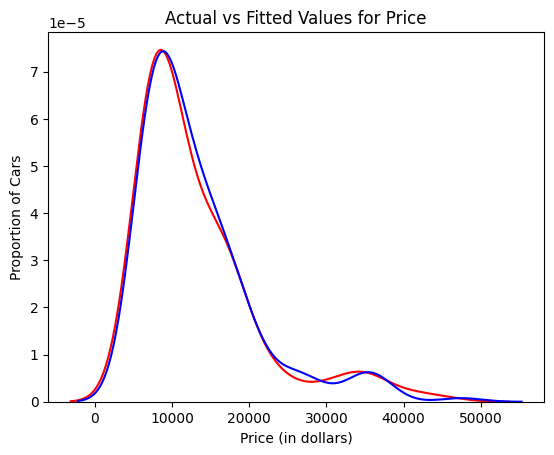

In [39]:
dist_plot(df['price'], Y_hat)

# 3 Models performance

Some classic performance metrics are:

<details><summary>R-Squared</summary>
$$R^2
=
1
-
\frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}
{\sum_{i=1}^n (y_i - \bar{y})^2}
$$
</details>
<details><summary>Mean Squared Error (MSE)</summary>
$$\text{MSE}
=
\frac{1}{n}
\sum_{i=1}^n
\left( y_i - \hat{y}_i \right)^2
$$
</details>
<details><summary>Root Mean Squared Error (RMSE)</summary>
$$\text{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^n
\left( y_i - \hat{y}_i \right)^2
}
$$
</details>
<details><summary>Mean Absolute Error (MAE)</summary>
$$\text{MAE}
=
\frac{1}{n}
\sum_{i=1}^n
\left|
y_i - \hat{y}_i
\right|
$$
</details>
<details><summary>Mean Absolute Percentage Error (MAPE)</summary>
$$\text{MAPE}
=
\frac{100}{n}
\sum_{i=1}^n
\left|
\frac{y_i - \hat{y}_i}{y_i}
\right|
$$
</details>

📘 31. Import from `sklearn.metrics` the following elements:
- `mean_absolute_error`
- `mean_squared_error`
- `r2_score`
- `mean_absolute_percentage_error`

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

📘 32. Run the code below. Then give a brief interpretation of the overall performance across models.

In [41]:
models = {
    "Single linear": simple_OLS,
    "Multiple linear": Multiple_OLS,
    "Single polynomial": poly_OLS,
    "Multiple Polynomial": poly_multiple_OLS
}

results = []

for name, model in models.items():
    y_pred = model.fittedvalues

    mse = mean_squared_error(Y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(Y, y_pred)
    mae = mean_absolute_error(Y, y_pred)
    mape = mean_absolute_percentage_error(Y, y_pred)


    results.append({
        "Model": name,
        "R²": round(r2, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),
        "MAPE": round(mape, 2)
    })

results_df = pd.DataFrame(results)
results_df

,Model,R²,MSE,RMSE,MAE,MAPE
0,Single linear,0.50,31635042.94,5624.50,4054.99,0.33
1,Multiple linear,0.81,11976801.68,3460.75,2450.43,0.18
2,Single polynomial,0.67,20474146.43,4524.84,2951.93,0.22
3,Multiple Polynomial,0.90,6579828.89,2565.12,1711.85,0.13
